In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# loading data into dataframes
balance_sheet = pd.read_excel('Balance_Sheet.xlsx')
income_statement = pd.read_excel('Income_Statement.xlsx')

In [14]:
# merging dataframes into 1 dataframe
df_ratios = pd.merge(balance_sheet, income_statement, on=['company', 'comp_type', 'Year'])
df_ratios.head()

,Unnamed: 0_x,Year,comp_type,company,Accounts Payable,Cash,Inventory,Property Plant Equipment,Short Term Investments,Total Assets,Total Current Assets,Total Current Liabilities,Total Liab,Total Stockholder Equity,Unnamed: 0_y,Cost Of Goods Sold,Gross Profit,Operating Income,Total Operating Expenses,Total Revenue
0,0,2019,tech,AAPL,46236000000,48844000000,4.106000e+09,37378000000,5.171300e+10,338516000000,162819000000,105718000000,248028000000,90488000000,0,161782000000,98392000000,63930000000,196244000000,260174000000
1,1,2020,tech,AAPL,42296000000,38016000000,4.061000e+09,45336000000,5.292700e+10,323888000000,143713000000,105392000000,258549000000,65339000000,1,169559000000,104956000000,66288000000,208227000000,274515000000
2,2,2021,tech,AAPL,54763000000,34940000000,6.580000e+09,49527000000,2.769900e+10,351002000000,134836000000,125481000000,287912000000,63090000000,2,212981000000,152836000000,108949000000,256868000000,365817000000
3,3,2022,tech,AAPL,64115000000,23646000000,4.946000e+09,84234000000,2.465800e+10,352755000000,135405000000,153982000000,302083000000,50672000000,3,223546000000,170782000000,119437000000,274891000000,394328000000
4,4,2019,tech,MSFT,9382000000,11356000000,2.063000e+09,43856000000,1.224760e+11,286556000000,175552000000,69420000000,184226000000,102330000000,4,42910000000,82933000000,42959000000,82884000000,125843000000


In [16]:
# computing for leverage and profitability ratio
df_ratios['leverage_ratio'] = df_ratios['Total Liab'] / df_ratios['Total Stockholder Equity']
df_ratios['profitability_ratio'] = df_ratios['Operating Income'] / df_ratios['Total Revenue']

In [18]:
# answering the question what comp_type has the lowest profitability ratio
lowest_profitability = df_ratios[['comp_type', 'profitability_ratio']]
lowest_profitability = lowest_profitability.groupby('comp_type').mean().sort_values(by='profitability_ratio').reset_index()
lowest_profitability = lowest_profitability.comp_type[0]

In [24]:
print(lowest_profitability)

fmcg


In [28]:
# answering the question what comp_type has the lowest profitability ratio
highest_leverage = df_ratios[['comp_type', 'leverage_ratio']]
highest_leverage = highest_leverage.groupby('comp_type').mean().sort_values(by='leverage_ratio').reset_index()
highest_leverage = highest_leverage.comp_type[2]

In [30]:
# answering the question what comp_type has the highest leverage ratio
print(highest_leverage)

real_est


In [32]:
# creating a dataframe that will be used to check if there are any relationship between leverage and profitability ratio
plotting = df_ratios[['leverage_ratio', 'profitability_ratio']][(df_ratios['comp_type'] == 'real_est')]

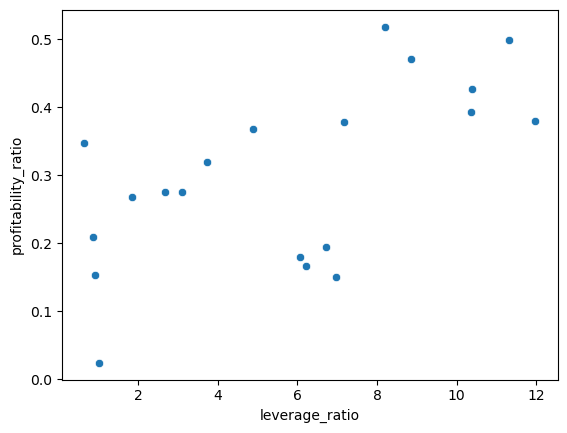

In [34]:
sns.scatterplot(x='leverage_ratio', y='profitability_ratio', data=plotting)
plt.show()

In [ ]:
# based on the chart above, we can see that there is a direct relatioship between leverage and profitability ratio